In [36]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn import metrics

# 1. EDA

In [2]:
df = pd.read_csv("1 - Project Data.csv")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [4]:
df.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Reason         5174
dtype: int64

In [6]:
df['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [21]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Reason             str
dtype: object

In [10]:
df.shape

(7043, 31)

# 2. Cleaning

In [11]:
df_clean = df.copy()

In [12]:
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce').fillna(0.0)

In [13]:
addons = ['Online Security', 'Online Backup', 'Device Protection',
          'Tech Support', 'Streaming TV', 'Streaming Movies']
df_clean[addons] = df_clean[addons].replace('No internet service', 'No')
df_clean['Multiple Lines'] = df_clean['Multiple Lines'].replace('No phone service', 'No')

# 3. Feature Engineering

In [14]:
DROPS = [
    "Count", "Country", "State",
    "CustomerID",
    "Churn Label", "Churn Value",
    "Churn Reason",
    "Lat Long",
    "City", "Zip Code", "Latitude", "Longitude",
    "Total Charges",
]

customer_ids = df_clean["CustomerID"]
y = df_clean["Churn Value"]
X = df_clean.drop(columns=DROPS)

In [15]:
X_enc = pd.get_dummies(X, drop_first=True, dtype=int)
FEATURE_COLUMNS = list(X_enc.columns)

In [16]:
X_enc.head()

,Tenure Months,Monthly Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,...,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,2,70.70,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
2,8,99.65,0,0,0,1,1,1,1,0,...,1,0,1,1,0,0,1,0,1,0
3,28,104.80,0,0,1,1,1,1,1,0,...,1,1,1,1,0,0,1,0,1,0
4,49,103.70,1,0,0,1,1,1,1,0,...,1,0,1,1,0,0,1,0,0,0


# 4. Scaling

In [19]:
NUMERIC = ["Tenure Months", "Monthly Charges"]

scaler = StandardScaler()
X_enc[NUMERIC] = scaler.fit_transform(X_enc[NUMERIC])

In [20]:
X_enc[NUMERIC].describe()

,Tenure Months,Monthly Charges
count,7.043000e+03,7.043000e+03
mean,-1.614182e-17,-5.649637e-17
std,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00
25%,-9.516817e-01,-9.725399e-01
50%,-1.372744e-01,1.857327e-01
75%,9.214551e-01,8.338335e-01
max,1.613701e+00,1.794352e+00


# 5. Fitting the Model

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=300, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",300
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [29]:
model.score(X_test, y_test)

0.8019872249822569

In [32]:
results = X_test.copy()
results[['prob_stay', 'prob_churn']] = model.predict_proba(X_test)
results['y_pred'] = np.where(results['prob_churn'] > .5, 1, 0)

roc_auc_score(y_test, results['prob_churn'])

0.8467204009403497

In [33]:
results.head()

,Tenure Months,Monthly Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,...,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,prob_stay,prob_churn,y_pred
2196,1.613701,1.638143,1,0,1,0,1,1,1,0,...,1,0,1,1,1,0,0,0.945875,0.054125,0
3549,-0.992402,1.176164,0,1,0,0,1,1,1,0,...,1,0,0,1,1,0,0,0.308896,0.691104,1
3515,0.351370,0.451620,0,0,1,0,1,1,0,0,...,0,1,0,1,1,0,0,0.889008,0.110992,0
5162,-0.585198,0.446635,1,0,1,0,1,0,1,0,...,0,0,0,0,0,1,0,0.523919,0.476081,0
4642,1.613701,0.594535,0,0,1,0,1,1,0,0,...,1,0,1,1,1,0,0,0.967293,0.032707,0


# 6. Metrics

In [37]:
def produce_confusion(positive_label, negative_label, cut_off, df, y_pred_name, y_real_name):
    pred = df[y_pred_name] if cut_off == 'binary' else np.where(df[y_pred_name] > cut_off, 1, 0)

    cm = confusion_matrix(df[y_real_name], pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap='Blues', cbar=False)

    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('Real labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels([negative_label, positive_label])
    ax.yaxis.set_ticklabels([negative_label, positive_label])
    plt.show()

    acc = accuracy_score(df[y_real_name], pred)
    print('Test accuracy = ', acc)
    return acc

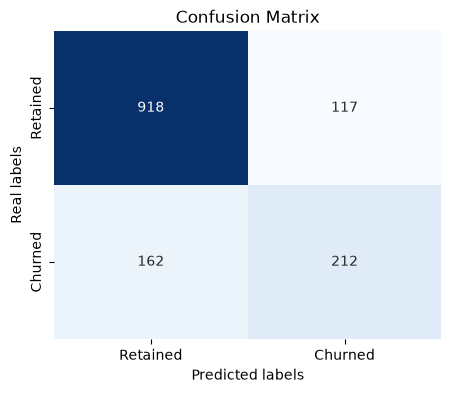

Test accuracy =  0.8019872249822569


0.8019872249822569

In [39]:
results['y_real'] = y_test
produce_confusion('Churned', 'Retained', 'binary', results, 'y_pred', 'y_real')

In [40]:
print(metrics.classification_report(y_test, results['y_pred']))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



# 7. Finding the Best Threshold Value

In [41]:
for cut in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    pred = np.where(results['prob_churn'] > cut, 1, 0)
    print(f"{cut:.2f}  acc {metrics.accuracy_score(y_test, pred):.3f}"
          f"  recall {metrics.recall_score(y_test, pred):.3f}"
          f"  precision {metrics.precision_score(y_test, pred):.3f}"
          f"  f1 {metrics.f1_score(y_test, pred):.3f}")

0.20  acc 0.718  recall 0.858  precision 0.483  f1 0.618
0.25  acc 0.740  recall 0.786  precision 0.507  f1 0.616
0.30  acc 0.762  recall 0.746  precision 0.537  f1 0.624
0.35  acc 0.776  recall 0.717  precision 0.561  f1 0.629
0.40  acc 0.780  recall 0.663  precision 0.574  f1 0.615
0.45  acc 0.794  recall 0.615  precision 0.612  f1 0.613
0.50  acc 0.802  recall 0.567  precision 0.644  f1 0.603


In [42]:
results['y_pred'] = np.where(results['prob_churn'] > 0.35, 1, 0)
results.head()

,Tenure Months,Monthly Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,...,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,prob_stay,prob_churn,y_pred,y_real
2196,1.613701,1.638143,1,0,1,0,1,1,1,0,...,0,1,1,1,0,0,0.945875,0.054125,0,0
3549,-0.992402,1.176164,0,1,0,0,1,1,1,0,...,0,0,1,1,0,0,0.308896,0.691104,1,0
3515,0.351370,0.451620,0,0,1,0,1,1,0,0,...,1,0,1,1,0,0,0.889008,0.110992,0,0
5162,-0.585198,0.446635,1,0,1,0,1,0,1,0,...,0,0,0,0,1,0,0.523919,0.476081,1,0
4642,1.613701,0.594535,0,0,1,0,1,1,0,0,...,0,1,1,1,0,0,0.967293,0.032707,0,0


# 8. The 500 Customers Most Likely to Churn

In [50]:
scored = df_clean[["CustomerID", "Churn Value", "City", "Zip Code",
                   "Tenure Months", "Contract", "Internet Service",
                   "Online Security", "Tech Support", "Payment Method",
                   "Monthly Charges", "Total Charges"]].copy()

scored[["prob_stay", "prob_churn"]] = model.predict_proba(X_enc)

retained = scored[scored["Churn Value"] == 0].drop(columns="Churn Value")
mailer_list = retained.sort_values("prob_churn", ascending=False).head(500)

In [51]:
mailer_list.head()

,CustomerID,City,Zip Code,Tenure Months,Contract,Internet Service,Online Security,Tech Support,Payment Method,Monthly Charges,Total Charges,prob_stay,prob_churn
4624,3489-HHPFY,Amboy,92304,2,Month-to-month,Fiber optic,No,No,Electronic check,84.05,134.05,0.145981,0.854019
4198,5150-ITWWB,Hamilton City,95951,3,Month-to-month,Fiber optic,No,No,Electronic check,94.85,335.75,0.147506,0.852494
3732,4927-WWOOZ,Pacific Grove,93950,2,Month-to-month,Fiber optic,No,No,Electronic check,91.45,171.45,0.147761,0.852239
2567,6630-UJZMY,Palo Alto,94306,4,Month-to-month,Fiber optic,No,No,Electronic check,83.25,308.05,0.150869,0.849131
3141,7398-SKNQZ,Downey,90241,3,Month-to-month,Fiber optic,No,No,Electronic check,94.90,273.20,0.162631,0.837369


In [52]:
mailer_list.to_csv("mailer_list_500.csv", index=False)

In [67]:
mailer_list["expected_saved_revenue"] = (
    mailer_list["prob_churn"] * mailer_list["Monthly Charges"] * 0.20)

print("Monthly revenue on the list :", mailer_list["Monthly Charges"].sum().round(2))
print("Expected churners           :", mailer_list["prob_churn"].sum().round(1))
print("Expected saves at 20%       :", (mailer_list["prob_churn"].sum() * 0.20).round(1))
print("Monthly revenue protected   :", mailer_list["expected_saved_revenue"].sum().round(2))
print("Annualised                  :", (mailer_list["expected_saved_revenue"].sum() * 12).round(2))

Monthly revenue on the list : 40060.25
Expected churners           : 321.6
Expected saves at 20%       : 64.3
Monthly revenue protected   : 5189.0
Annualised                  : 62268.05


# 9. Churn Risk of Remaining Customers

In [54]:
risk_register = retained.copy()
risk_register["churn_risk_pct"] = (risk_register["prob_churn"] * 100).round(1)
risk_register["risk_band"] = pd.cut(
    risk_register["prob_churn"],
    bins=[0, .10, .25, .45, .65, 1.0],
    labels=["Very low", "Low", "Medium", "High", "Very high"])

risk_register = risk_register.sort_values("CustomerID")
risk_register.to_csv("churn_risk_register.csv", index=False)

In [63]:
band_summary = risk_register.groupby("risk_band", observed=True).agg(
    customers=("CustomerID", "size"),
    mean_risk=("churn_risk_pct", "mean"),
    monthly_revenue=("Monthly Charges", "sum"),
    mean_monthly_revenue=("Monthly Charges", "mean"),
)
band_summary["share"] = (band_summary["customers"] / len(risk_register) * 100).round(1)
band_summary = band_summary[["customers", "share", "mean_risk", "mean_monthly_revenue", "monthly_revenue"]].round(1)
band_summary

,customers,share,mean_risk,mean_monthly_revenue,monthly_revenue
risk_band,,,,,
Very low,2722,52.6,3.4,55.1,149870.2
Low,1056,20.4,16.6,61.9,65387.6
Medium,732,14.1,33.8,67.0,49067.8
High,450,8.7,54.7,77.1,34707.0
Very high,214,4.1,72.4,83.9,17953.0


In [64]:
band_by_service = pd.crosstab(
    risk_register["risk_band"],
    risk_register["Internet Service"],
    normalize="index").mul(100).round(1)
band_by_service

Internet Service,DSL,Fiber optic,No
risk_band,,,
Very low,40.6,19.5,39.9
Low,37.2,36.9,25.9
Medium,46.9,45.6,7.5
High,25.3,74.7,0.0
Very high,3.3,96.7,0.0


# 10. What factors most influence someone churning?

In [55]:
coefficients = pd.DataFrame({
    "feature": X_enc.columns,
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0]),
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

coefficients["pct_change"] = ((coefficients["odds_ratio"] - 1) * 100).round(1)
coefficients

,feature,coefficient,odds_ratio,pct_change
0,Internet Service_Fiber optic,0.980581,2.666004,166.6
1,Payment Method_Electronic check,0.374670,1.454512,45.5
2,Multiple Lines_Yes,0.368765,1.445948,44.6
3,Paperless Billing_Yes,0.356059,1.427692,42.8
4,Streaming TV_Yes,0.340537,1.405702,40.6
5,Streaming Movies_Yes,0.316839,1.372781,37.3
6,Partner_Yes,0.281334,1.324896,32.5
7,Payment Method_Mailed check,0.099710,1.104850,10.5
8,Senior Citizen_Yes,0.024522,1.024825,2.5
9,Gender_Male,0.016015,1.016144,1.6


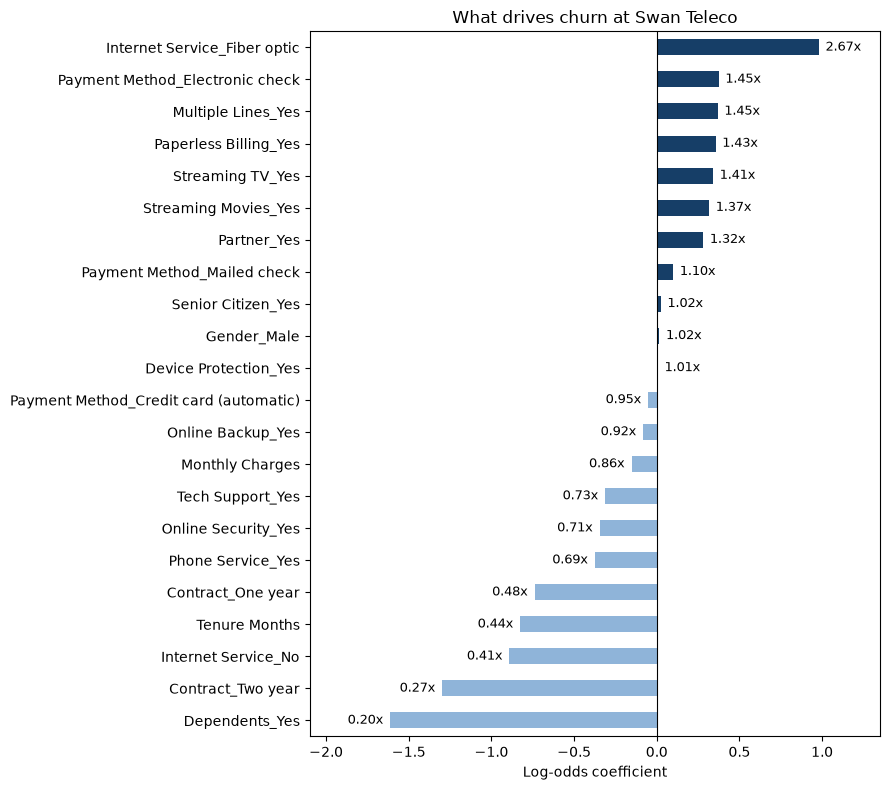

In [59]:
ax = plot_df.plot.barh(x="feature", y="coefficient", figsize=(9, 8),
                       legend=False, color=colours)
ax.axvline(0, color="black", linewidth=.8)

for bar, ratio in zip(ax.patches, plot_df["odds_ratio"]):
    w = bar.get_width()
    offset = 0.04 if w > 0 else -0.04
    ax.text(w + offset, bar.get_y() + bar.get_height()/2, f"{ratio:.2f}x",
            va="center", ha="left" if w > 0 else "right", fontsize=9)

ax.set_xlim(-2.1, 1.35)
ax.set_xlabel("Log-odds coefficient")
ax.set_ylabel("")
ax.set_title("What drives churn at Swan Teleco")
plt.tight_layout()
plt.show()

In [68]:
service_cols = ['Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']

coefs = pd.Series(model.coef_[0], index=X_enc.columns)

incentive = pd.DataFrame({
    "odds_ratio": [np.exp(coefs[c + "_Yes"]) for c in service_cols],
    "churn_with": [df_clean[df_clean[c] == "Yes"]["Churn Value"].mean() * 100 for c in service_cols],
    "churn_without": [df_clean[df_clean[c] == "No"]["Churn Value"].mean() * 100 for c in service_cols],
}, index=service_cols)

incentive.sort_values("odds_ratio").round(2)

,odds_ratio,churn_with,churn_without
Online Security,0.71,14.61,31.33
Tech Support,0.73,15.17,31.19
Online Backup,0.92,21.53,29.17
Device Protection,1.01,22.50,28.65
Streaming Movies,1.37,29.94,24.38
Streaming TV,1.41,30.07,24.33
